In [1]:
import anndata
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy




In [2]:

# --- INIT ---

head_folder = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint'
adata_path = '%s/adata_qc_filtered.h5ad' % head_folder
hvg_folder = '%s/data_annotations/hvg/prior_knowledge_guided' % head_folder #  transformed_X_outlier_variance
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder






In [3]:
# --- LOAD ADATA ---


adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- LOAD scvi_mean_embedding_df --- 


scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')


scvi_mean_embedding_df


,X_scVI_dim_0,X_scVI_dim_1,X_scVI_dim_2,X_scVI_dim_3,X_scVI_dim_4,X_scVI_dim_5,X_scVI_dim_6,X_scVI_dim_7,X_scVI_dim_8,X_scVI_dim_9
barcode,,,,,,,,,,
AAACCCAAGAATCGAT-1-11-1,-1.080696,-0.009422,-0.269604,-0.497371,-0.406448,0.090194,-0.441606,-0.376723,-0.177494,0.146045
AAACCCAAGAATCGCG-1-0,-0.415760,0.525750,0.637773,-0.606516,0.124656,0.409811,-0.025152,0.556938,0.262339,-0.549207
AAACCCAAGACAGCTG-1-2-1,-1.651087,-0.275378,0.186161,0.872300,0.678570,-0.150613,-0.718964,1.370230,-1.049866,0.729324
AAACCCAAGACATCAA-1-0,1.941469,-0.795005,1.621404,-0.960115,-0.030551,0.378386,-0.924918,-0.974665,1.562923,-2.064355
AAACCCAAGAGCAACC-1-2,-0.841718,-2.389380,-2.239438,1.421683,2.452373,-0.092109,-0.036172,-1.327129,-0.392820,1.228104
...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCTCTTGCG-1-2-1,-0.497249,1.389545,0.090392,-0.480469,-0.032963,0.263749,-1.688702,-0.556480,0.481997,0.025765
TTTGTTGTCTGAACGT-1-0,-0.735781,0.706214,0.442580,-0.555269,0.033154,0.249784,-0.425414,0.394865,0.448712,-0.005486
TTTGTTGTCTGAGGTT-1-1,1.845152,-1.962954,3.363190,1.102582,0.363194,-2.181166,1.560951,-0.809432,-2.853051,-1.048094


In [5]:
# --- MAKE SURE ADATA IN THE SAME ORDER AS THE SCVI MEAN EMBEDDING DF ---

adata = adata[list(scvi_mean_embedding_df.index)]
adata


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [6]:
# --- ADD SCVI EMBEDDING TO ADATA ---

adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)




In [7]:
# --- RUN UMAP ON THE scVI EMBEDDING ---


import umap


n_components = 2
n_neighbors = 300
min_dist = 0.1

metric = 'euclidean'
umap_embedding = umap.UMAP(n_neighbors=n_neighbors,
                  metric=metric, n_components = n_components).fit_transform(adata.obsm['X_scVI'])


adata.obsm['X_scVI_umap'] = umap_embedding





/anaconda2/envs/scrublet/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn("Tensorflow not installed; ParametricUMAP will be unavailable")


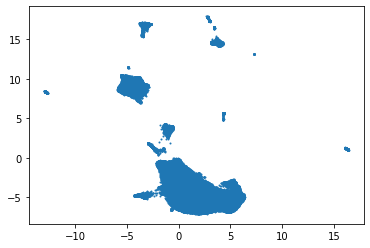

In [8]:
# --- VIZ ---

plt.clf()
plt.scatter(umap_embedding[:,0],umap_embedding[:,1],s=1)



In [9]:
# --- WRITE UMAP EMBEDDING OUT ---
umap_df = pd.DataFrame()
umap_df['barcode'] = np.array(adata.obs.index)
umap_df['umap1'] = np.array(adata.obsm['X_scVI_umap'][:,0])
umap_df['umap2'] = np.array(adata.obsm['X_scVI_umap'][:,1])
umap_df = umap_df.set_index("barcode")
umap_df.to_csv(umap_path_out,sep='\t')



In [10]:
# --- COMPUTE NEIGHBORS ---

scanpy.pp.neighbors(adata,use_rep='X_scVI',n_neighbors=20)




In [45]:
# --- CLUSTER ---

resolution = 0.2
scanpy.tl.leiden(adata, key_added="leiden_scvi_cluster", resolution = resolution)



In [46]:
# --- MAKE CLUSTER AN INT ---

adata.obs['leiden_scvi_cluster'] = adata.obs['leiden_scvi_cluster'].astype(int)




In [75]:
# --- WRITE THE CLUSTERS OUT ---

if not os.path.exists('%s/clustering' % scvi_res_folder):
    os.makedirs('%s/clustering' % scvi_res_folder)
cluster_folder_out = '%s/clustering/res_%s' % (scvi_res_folder, str(resolution))
if not os.path.exists(cluster_folder_out):
    os.makedirs(cluster_folder_out)
cluster_df_fileout = '%s/clusters.tsv' % cluster_folder_out
# cluster_df_fileout = '%s/scvi_mean_clusters_res_%s.tsv' % (scvi_res_folder, str(resolution))
adata.obs['leiden_scvi_cluster'].to_csv(cluster_df_fileout,sep='\t')




In [50]:
# --- TEMP: LOAD CLUSTERS ---

resolution = 0.05
cluster_folder_out = '%s/clustering/res_%s' % (scvi_res_folder, str(resolution))
cluster_df_fileout = '%s/clusters.tsv' % cluster_folder_out
df = pd.read_table(cluster_df_fileout,index_col='index')
adata.obs.loc[df.index,'leiden_scvi_cluster'] = np.array(df['leiden_scvi_cluster'])
# smc_adata = adata[adata.obs['cluster'] == 0]




<Figure size 432x288 with 0 Axes>

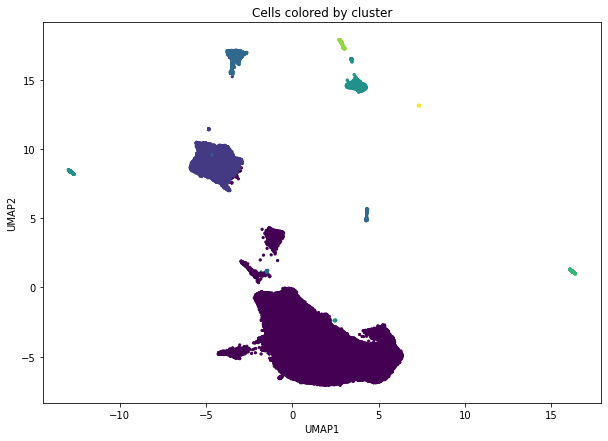

In [51]:
# --- VIZ CLUSTERS JOINTLY ---


plt.clf()
plt.figure(figsize=(10,7))
plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=5,c=np.array(adata.obs['leiden_scvi_cluster']).astype(int))
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Cells colored by cluster")
plt.show()






<Figure size 432x288 with 0 Axes>

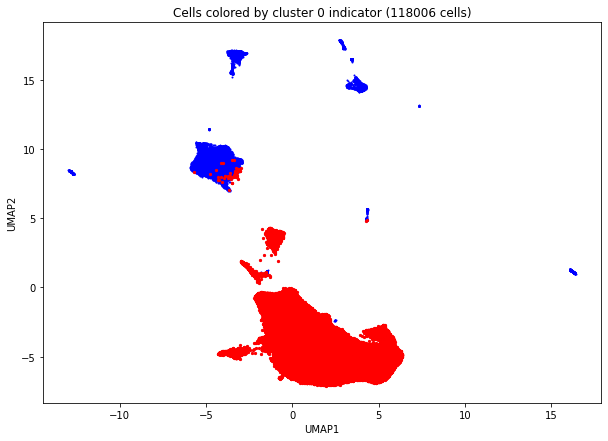

<Figure size 432x288 with 0 Axes>

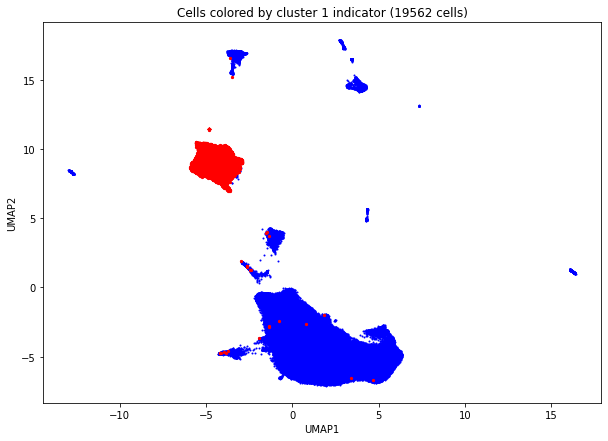

<Figure size 432x288 with 0 Axes>

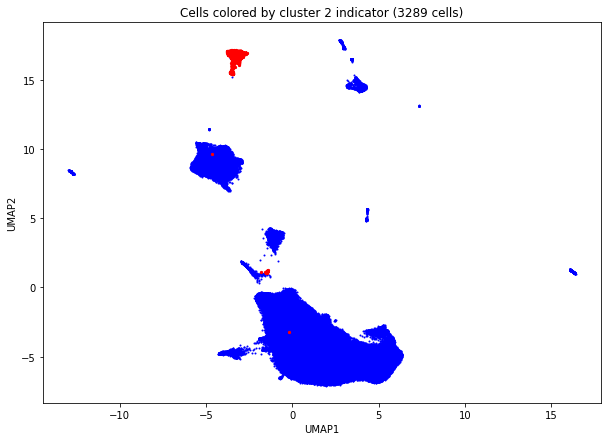

<Figure size 432x288 with 0 Axes>

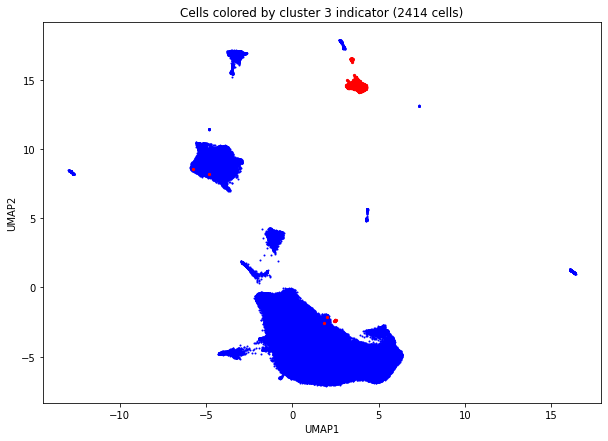

<Figure size 432x288 with 0 Axes>

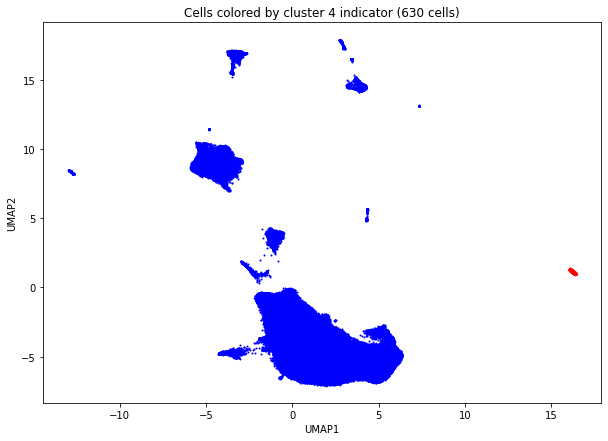

<Figure size 432x288 with 0 Axes>

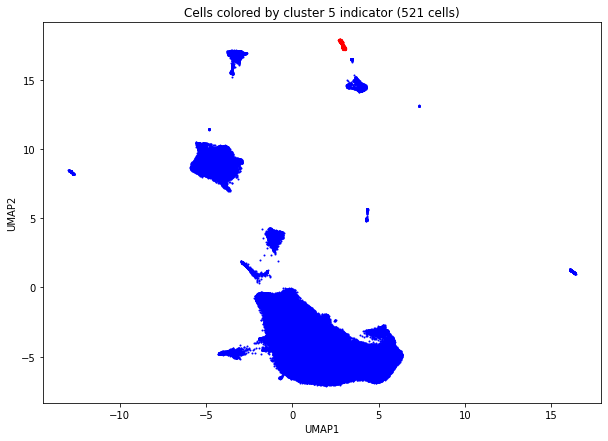

<Figure size 432x288 with 0 Axes>

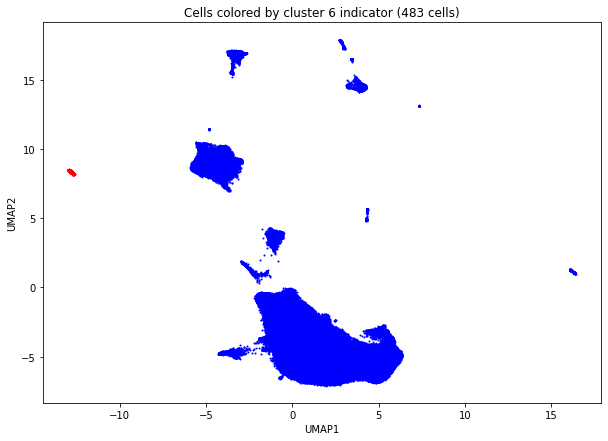

<Figure size 432x288 with 0 Axes>

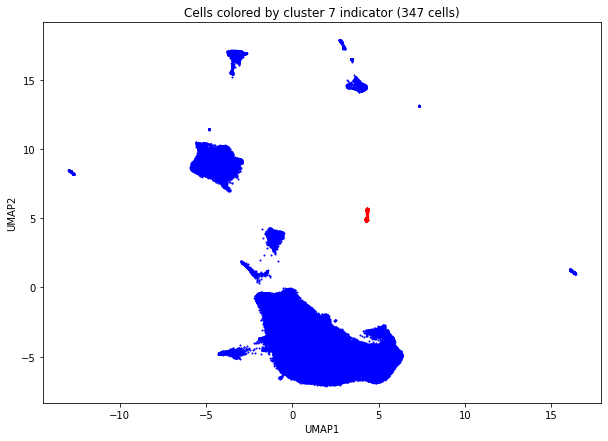

<Figure size 432x288 with 0 Axes>

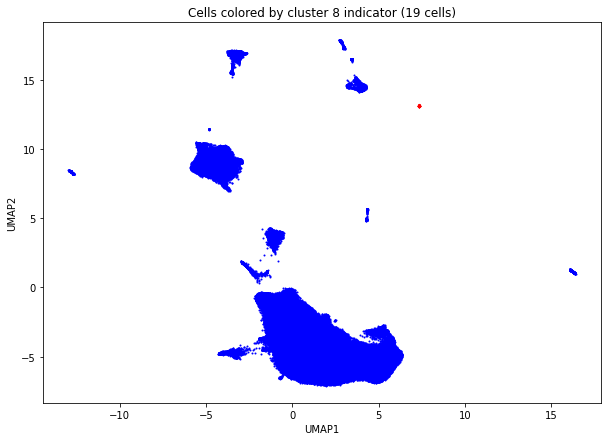

In [74]:
# --- VIZ CLUSTERS INDIVIDUALLY ---

unique_clusters = sorted(list(np.unique(np.array(adata.obs['leiden_scvi_cluster']).astype(int))))
for cluster in unique_clusters:
    
        
    cluster_indices = np.where(adata.obs['leiden_scvi_cluster'] == cluster)
    cluster_count = len(cluster_indices[0])
    
    plt.clf()
    plt.figure(figsize=(10,7))
    plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=1,c='b')
    plt.scatter(adata.obsm['X_scVI_umap'][cluster_indices,0],adata.obsm['X_scVI_umap'][cluster_indices,1],s=5,c='r')
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Cells colored by cluster %s indicator (%s cells)" % (cluster, cluster_count))
    plt.show()
    
    

In [16]:
# --- OBTAIN X TRANSFORMED ---

X_transformed = adata.X / np.array(adata.obs['lib_size']).reshape(-1,1)
X_transformed = np.array(X_transformed)
min_prop = 1e-7
X_transformed[X_transformed < min_prop] = min_prop
X_transformed = np.log10(X_transformed)
adata.layers['X_transformed'] = X_transformed



In [17]:
# --- MARKER DICT ---

marker_dict = {
    "SMC" : ["Myh11", "Acta2", "Tagln", "Cnn1"],
    'Modulated SMC' : ['Fn1', 'Lum', 'Frzb', 'Ly6c1', 'Ly6a', 'Vcam1'],
    "Fibroblast" : ['Serpinf1', 'Serping1', 'Cygb', 'Gsn'],
    'Macrophage 1' : ['C1qb'],
    'Macrophage 2' : ['Ctss'],
    'Macrophage' : ['Cd84'],
    'Endothelial' : ['Egfl7', 'Pecam1', 'Esam'],
    'T' : ['Cd3g', 'Cd3d', 'Lat'],
    'Transitioning SMC' : ['Rgs5']
}


<Figure size 432x288 with 0 Axes>

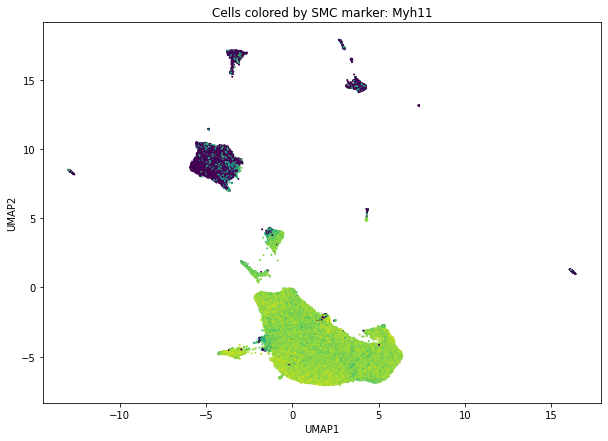

<Figure size 432x288 with 0 Axes>

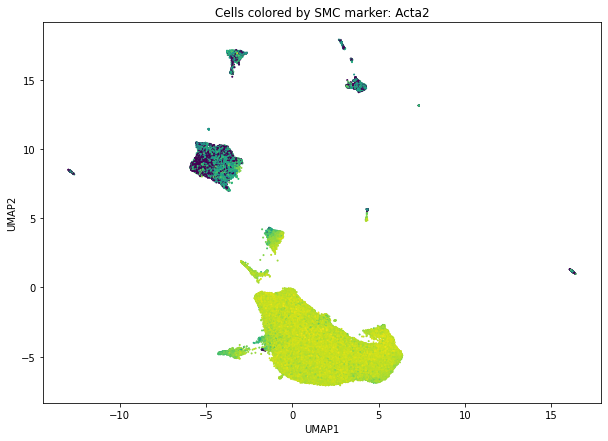

<Figure size 432x288 with 0 Axes>

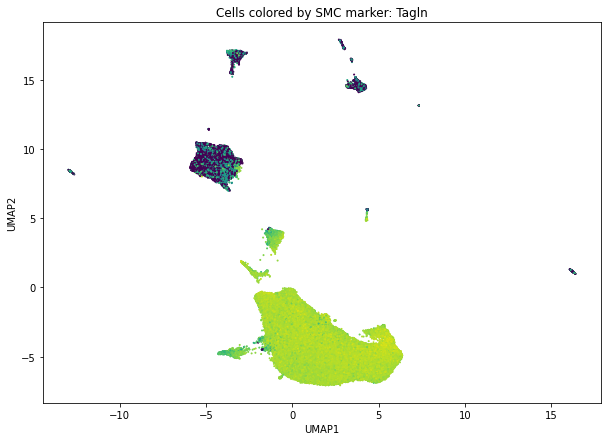

<Figure size 432x288 with 0 Axes>

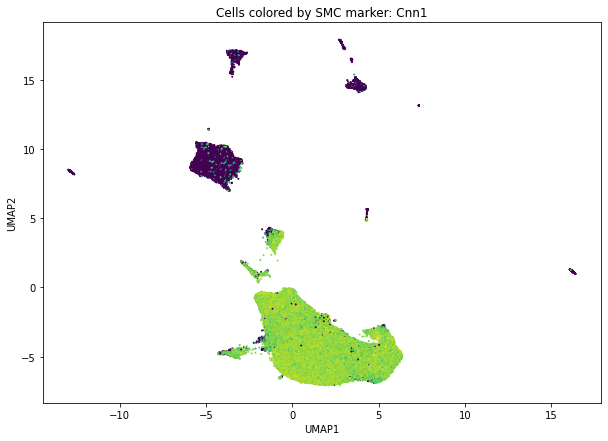

<Figure size 432x288 with 0 Axes>

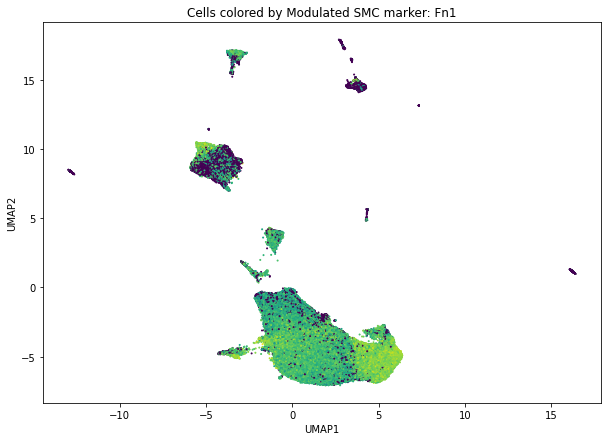

<Figure size 432x288 with 0 Axes>

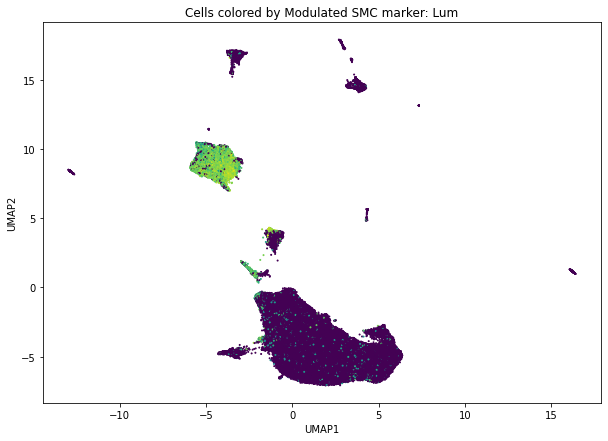

<Figure size 432x288 with 0 Axes>

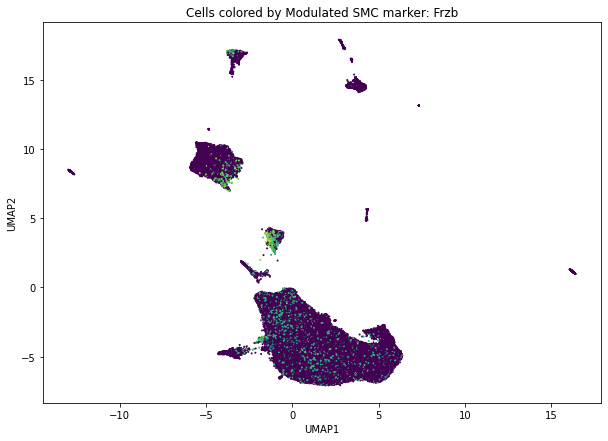

<Figure size 432x288 with 0 Axes>

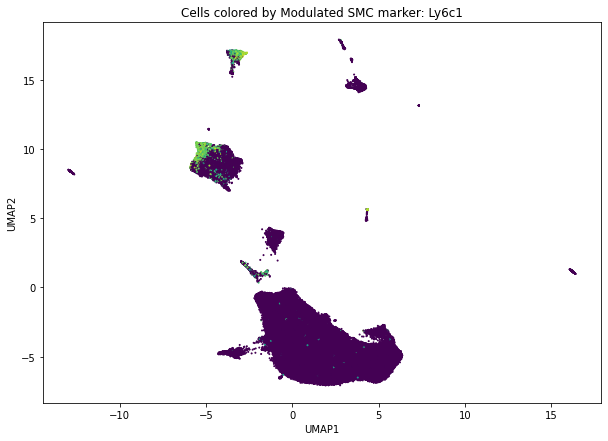

<Figure size 432x288 with 0 Axes>

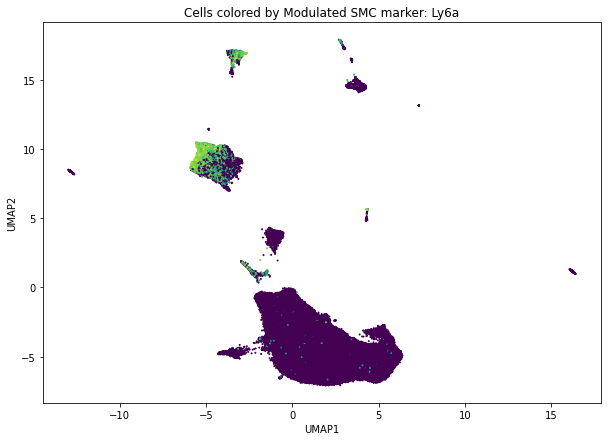

<Figure size 432x288 with 0 Axes>

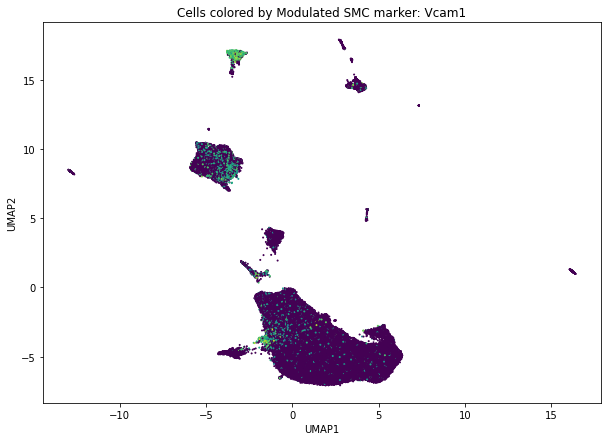

<Figure size 432x288 with 0 Axes>

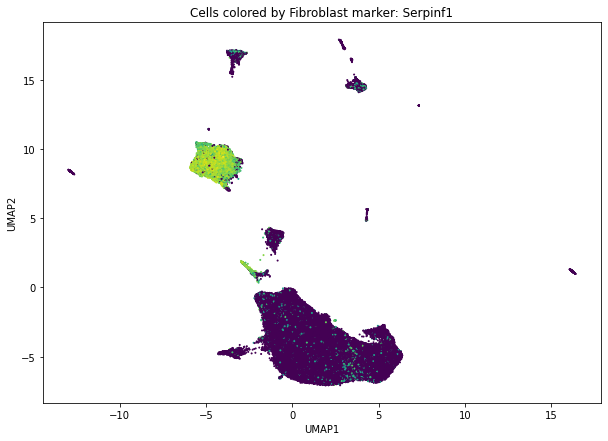

<Figure size 432x288 with 0 Axes>

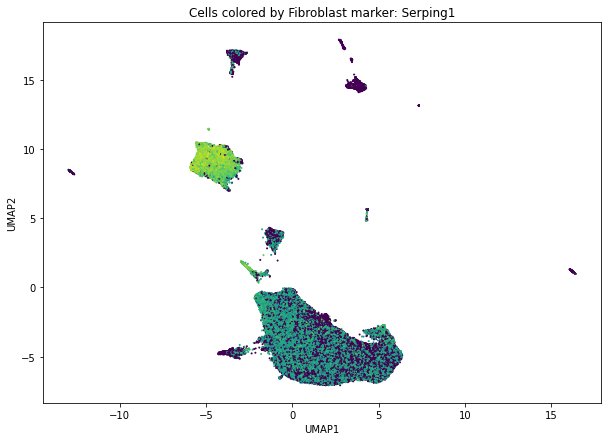

<Figure size 432x288 with 0 Axes>

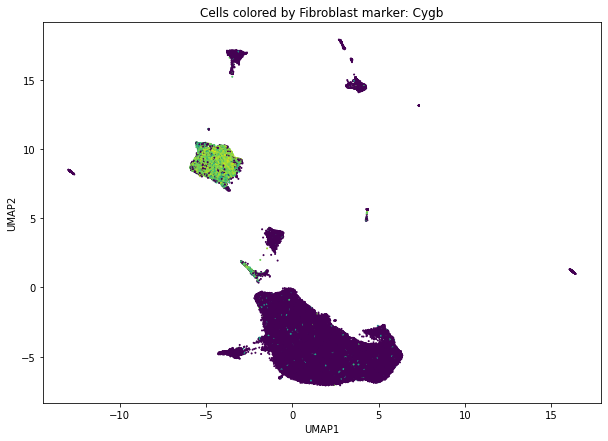

<Figure size 432x288 with 0 Axes>

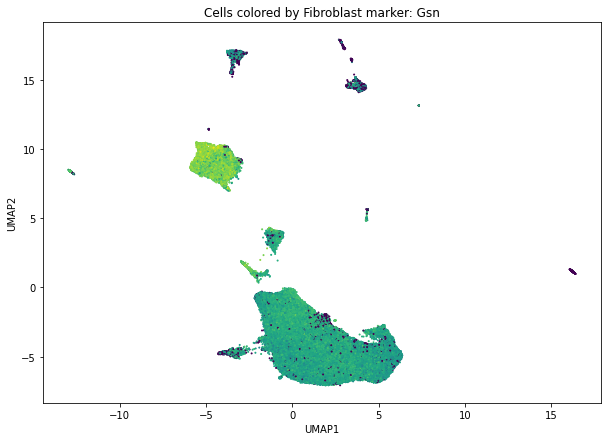

<Figure size 432x288 with 0 Axes>

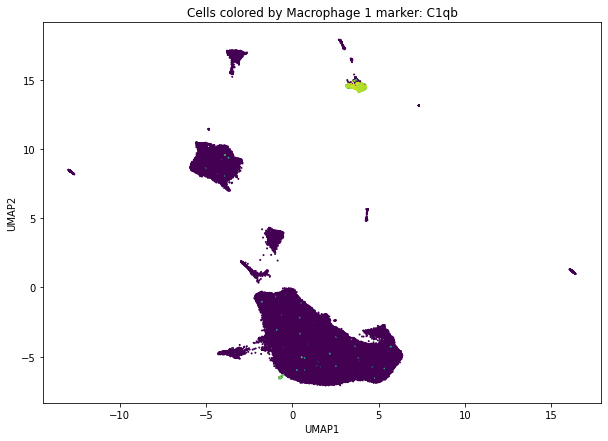

<Figure size 432x288 with 0 Axes>

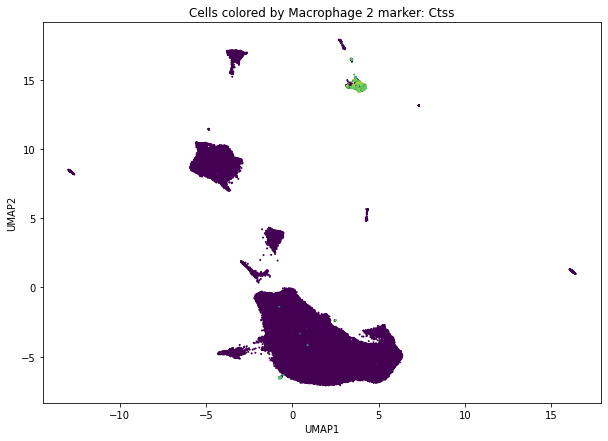

<Figure size 432x288 with 0 Axes>

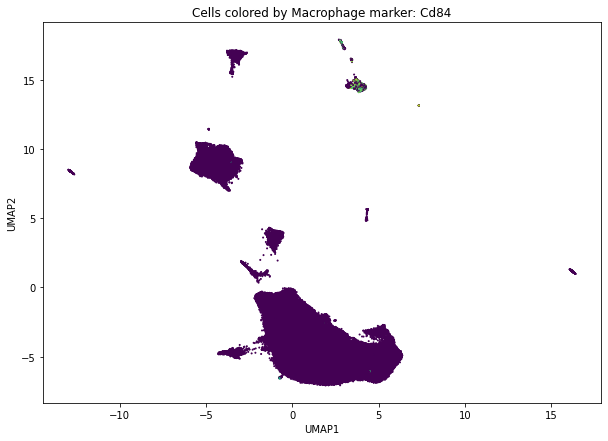

<Figure size 432x288 with 0 Axes>

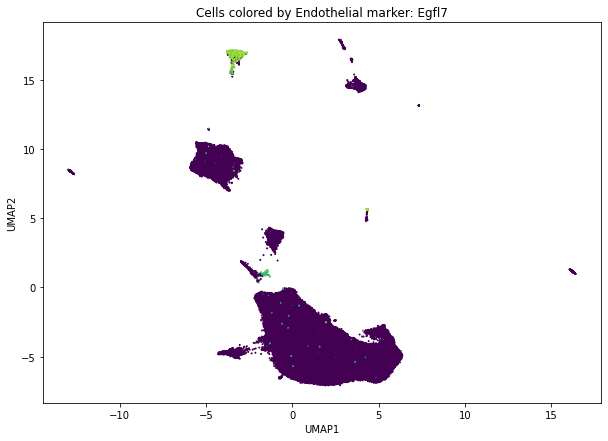

<Figure size 432x288 with 0 Axes>

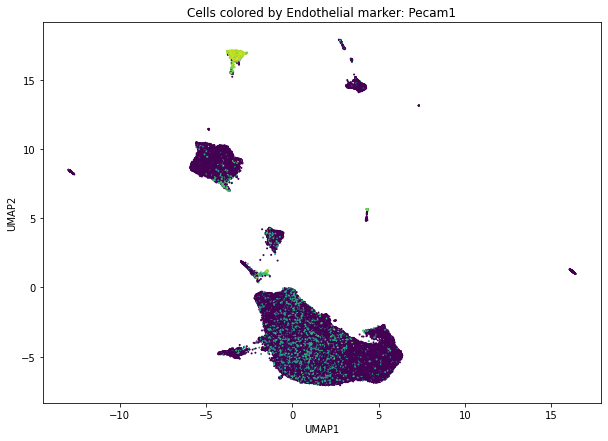

<Figure size 432x288 with 0 Axes>

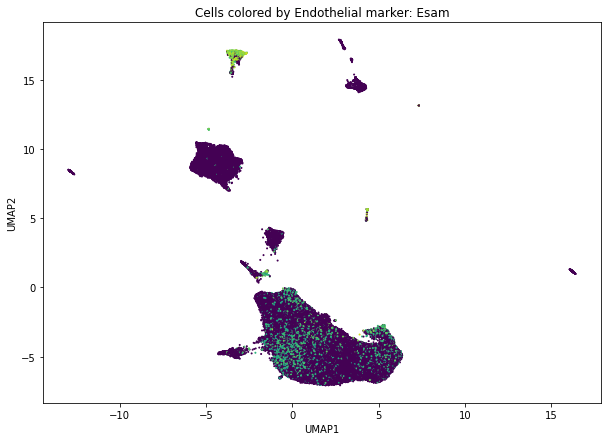

<Figure size 432x288 with 0 Axes>

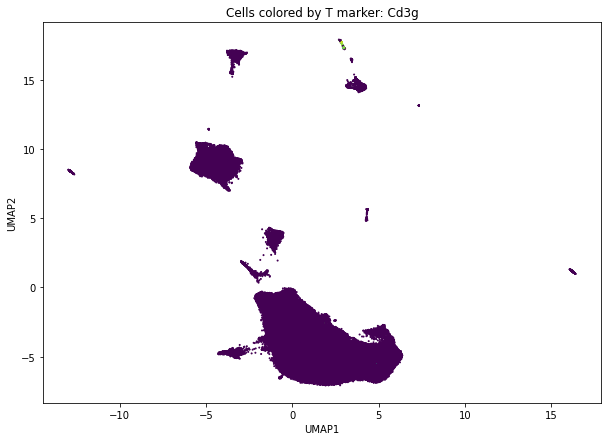

<Figure size 432x288 with 0 Axes>

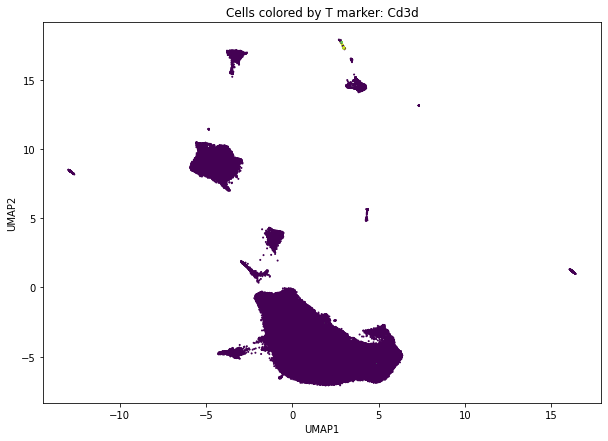

<Figure size 432x288 with 0 Axes>

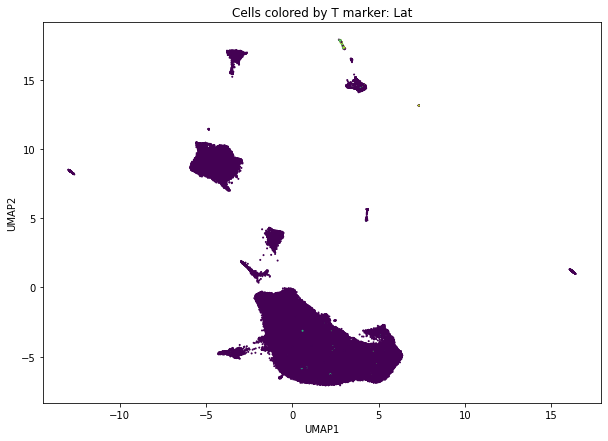

<Figure size 432x288 with 0 Axes>

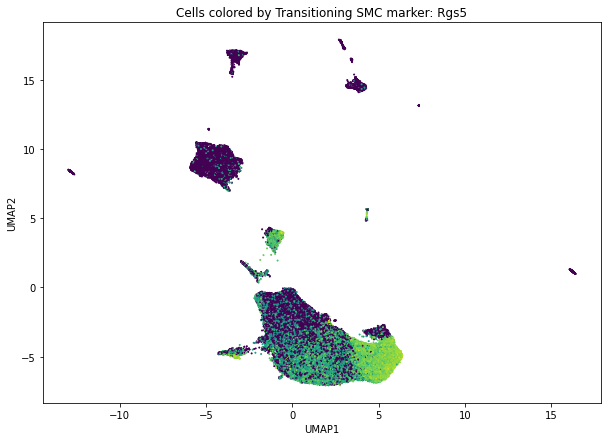

In [18]:
# --- VIZ CLUSTERS BY MARKERS ---

for cell_type, marker_list in marker_dict.items():
    for marker in marker_list:
        marker_index = np.where(adata.var_names == marker)[0]

        plt.clf()
        plt.figure(figsize=(10,7))
        plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c=X_transformed[:,marker_index].flatten())
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.title("Cells colored by %s marker: %s" % (cell_type, marker))
        plt.show()




<Figure size 432x288 with 0 Axes>

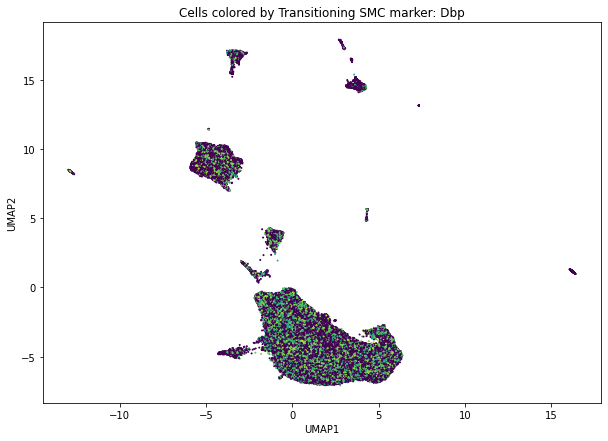

<Figure size 432x288 with 0 Axes>

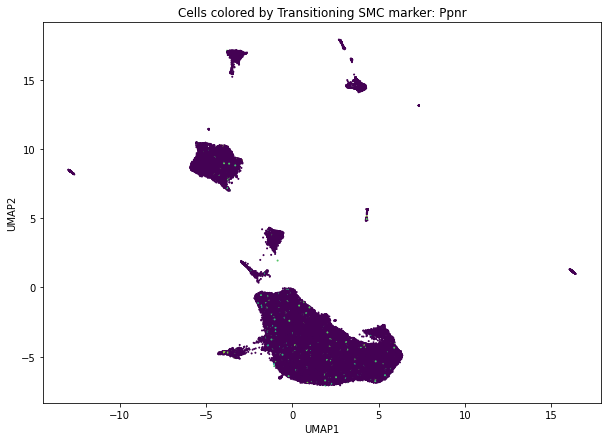

<Figure size 432x288 with 0 Axes>

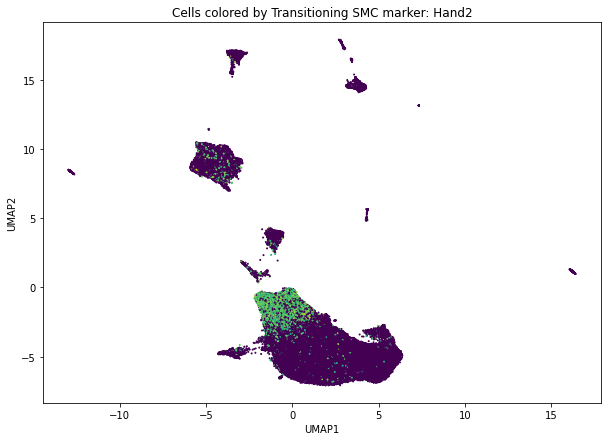

<Figure size 432x288 with 0 Axes>

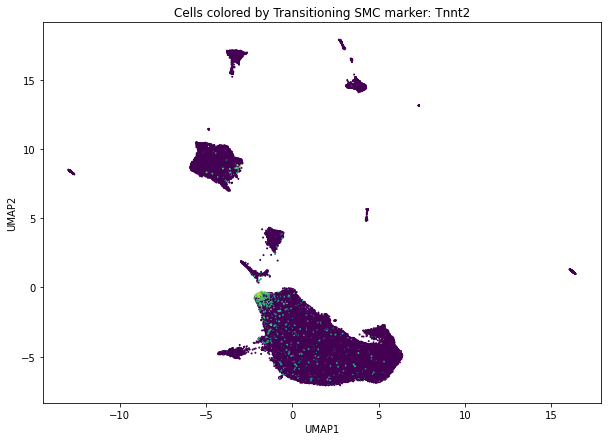

<Figure size 432x288 with 0 Axes>

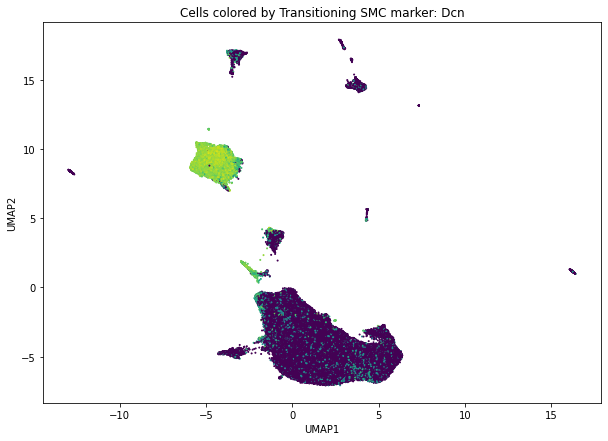

<Figure size 432x288 with 0 Axes>

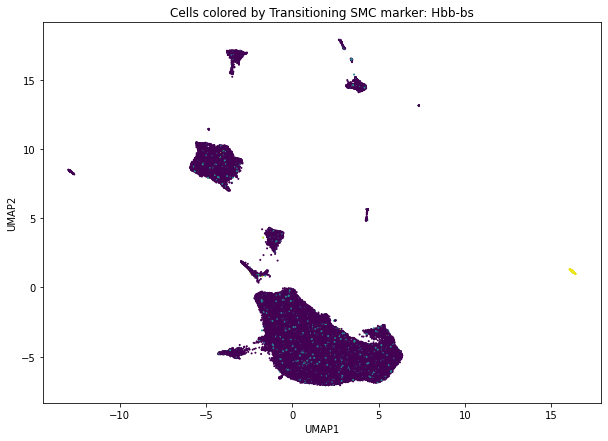

<Figure size 432x288 with 0 Axes>

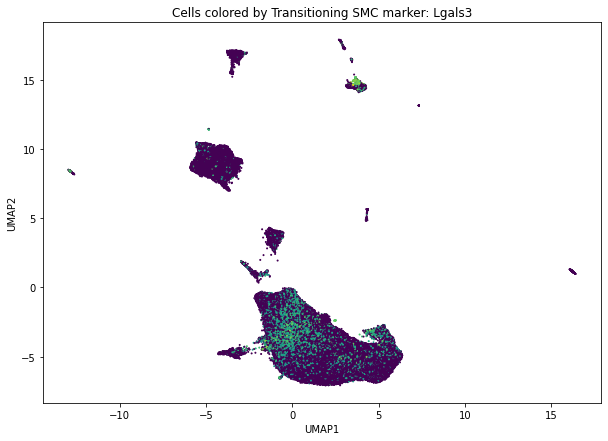

<Figure size 432x288 with 0 Axes>

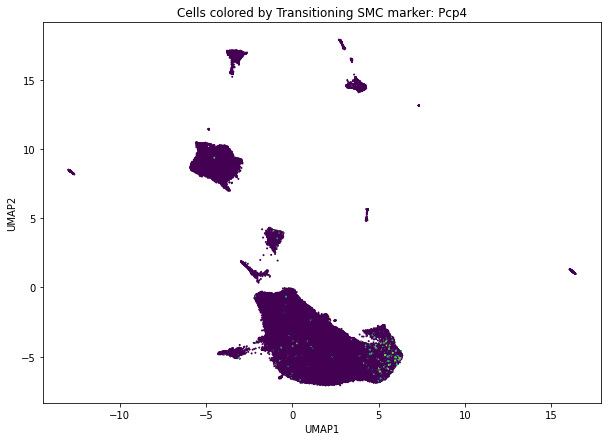

<Figure size 432x288 with 0 Axes>

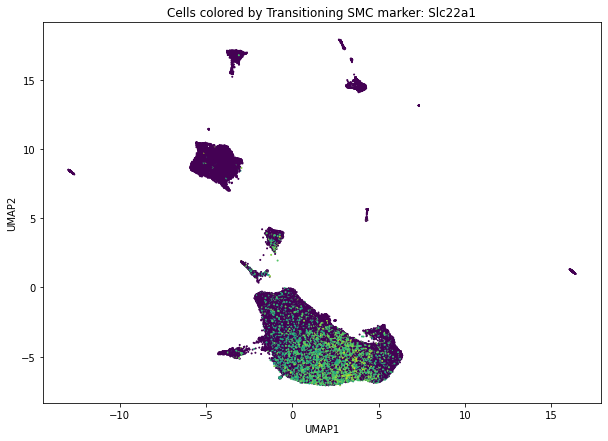

<Figure size 432x288 with 0 Axes>

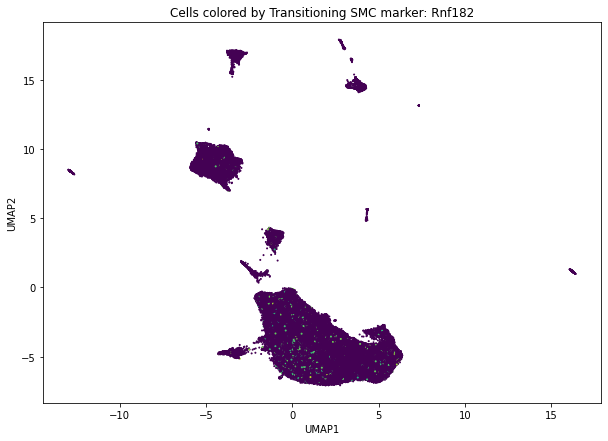

In [24]:
# --- VIZ CLUSTERS BY MARKERS ---

for marker in ['Dbp', 'Ppnr','Hand2','Tnnt2','Dcn','Hbb-bs','Lgals3','Pcp4','Slc22a1','Rnf182']:
    marker_index = np.where(adata.var_names == marker)[0]

    plt.clf()
    plt.figure(figsize=(10,7))
    plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c=X_transformed[:,marker_index].flatten())
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Cells colored by %s marker: %s" % (cell_type, marker))
    plt.show()




<Figure size 432x288 with 0 Axes>

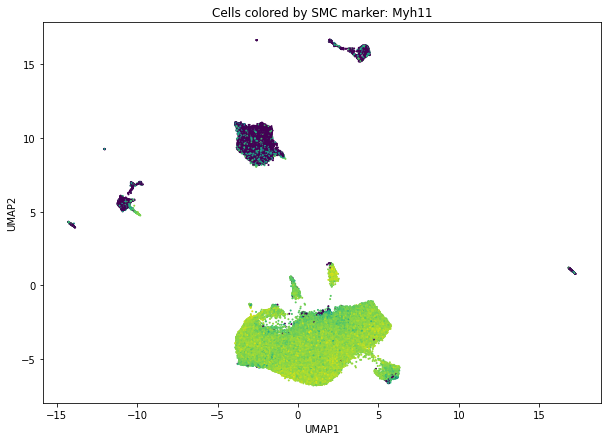

<Figure size 432x288 with 0 Axes>

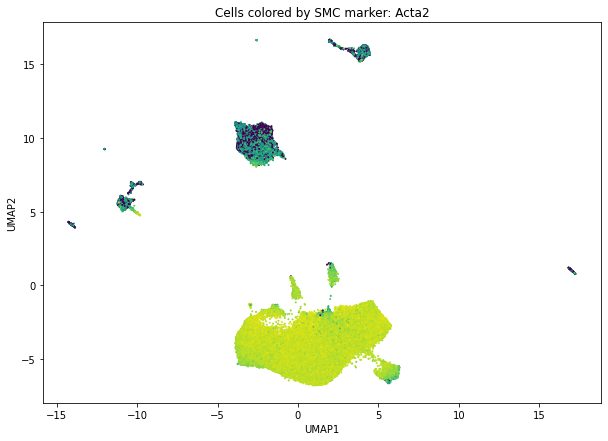

<Figure size 432x288 with 0 Axes>

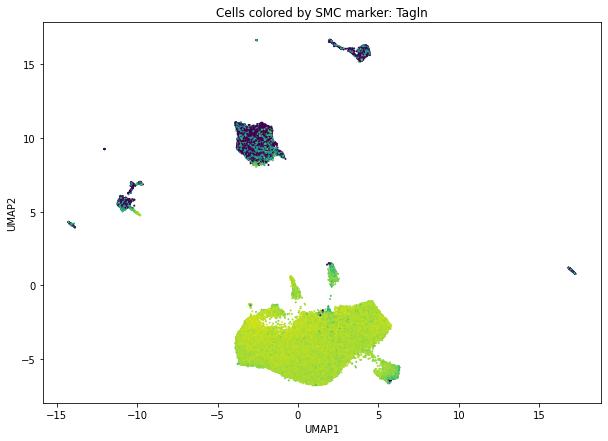

<Figure size 432x288 with 0 Axes>

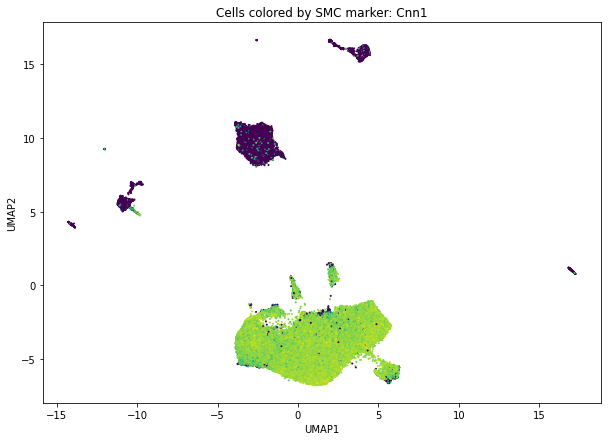

<Figure size 432x288 with 0 Axes>

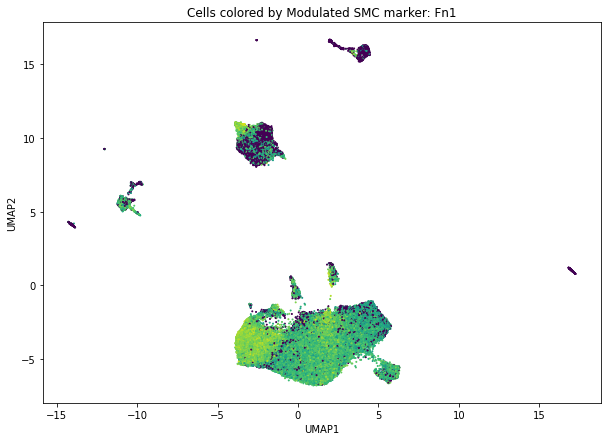

<Figure size 432x288 with 0 Axes>

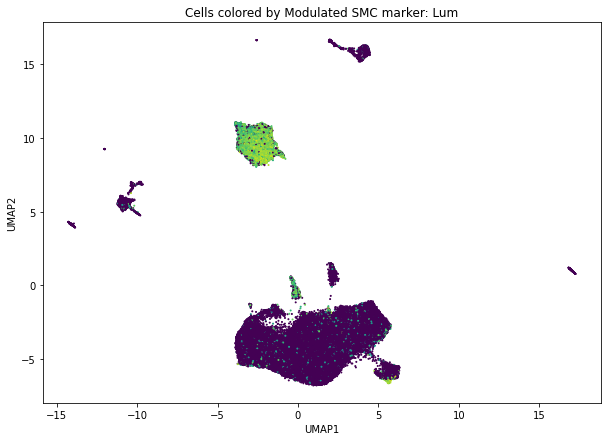

<Figure size 432x288 with 0 Axes>

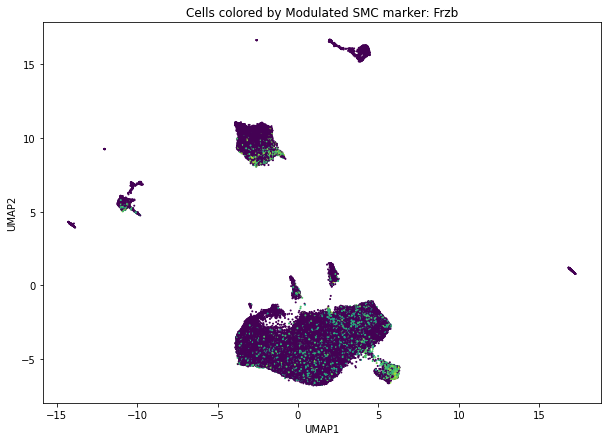

<Figure size 432x288 with 0 Axes>

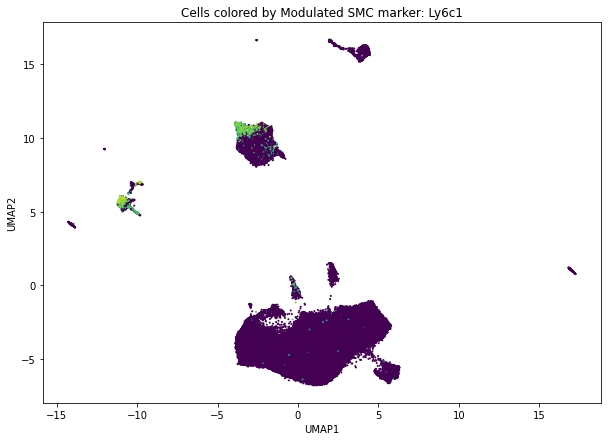

<Figure size 432x288 with 0 Axes>

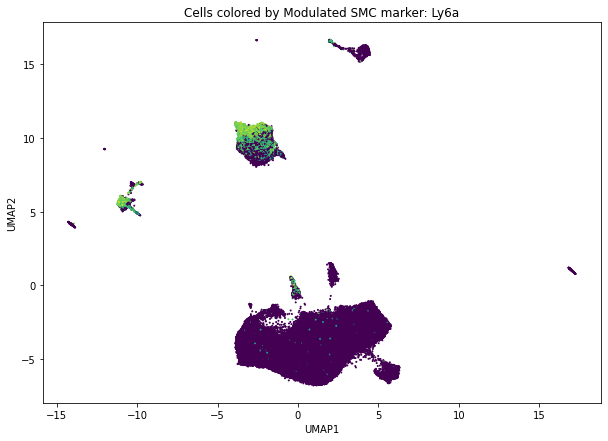

<Figure size 432x288 with 0 Axes>

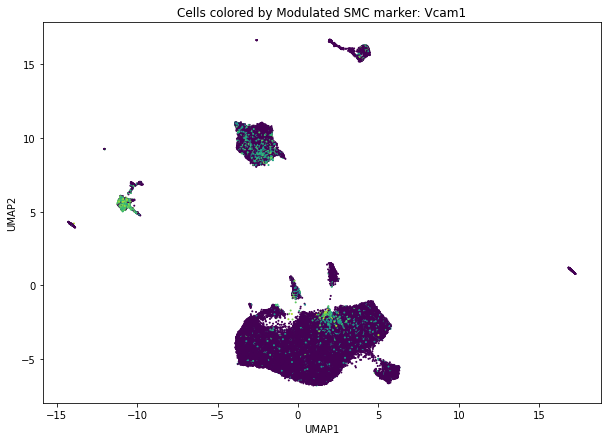

<Figure size 432x288 with 0 Axes>

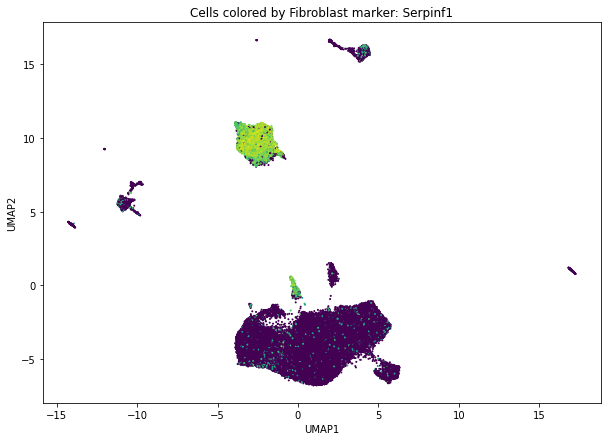

<Figure size 432x288 with 0 Axes>

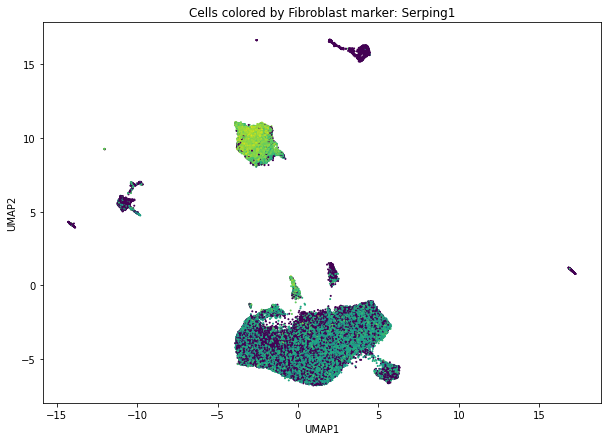

<Figure size 432x288 with 0 Axes>

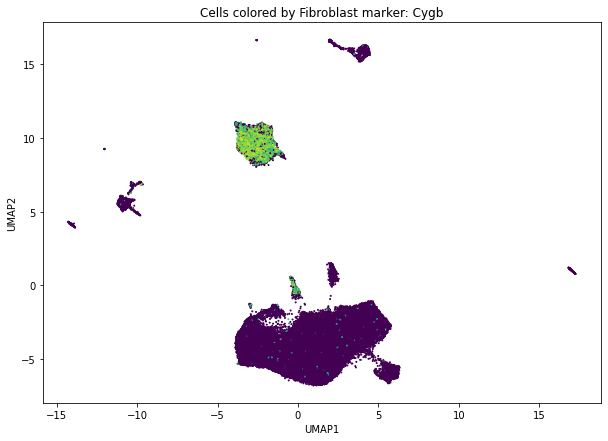

<Figure size 432x288 with 0 Axes>

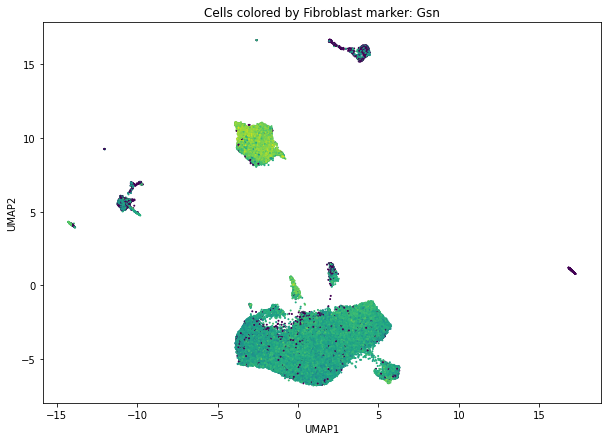

<Figure size 432x288 with 0 Axes>

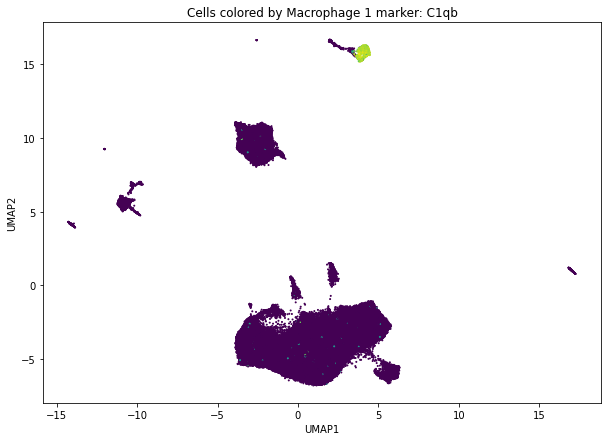

<Figure size 432x288 with 0 Axes>

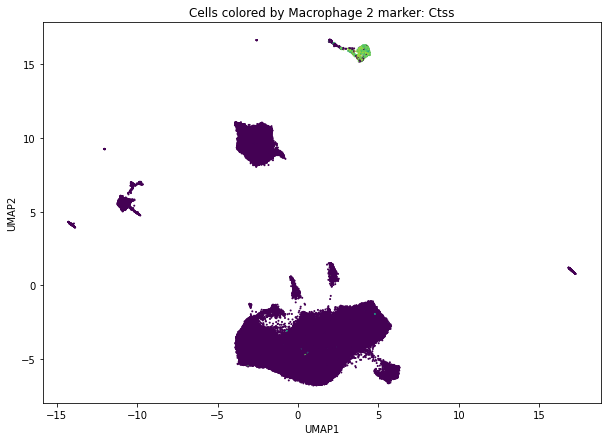

<Figure size 432x288 with 0 Axes>

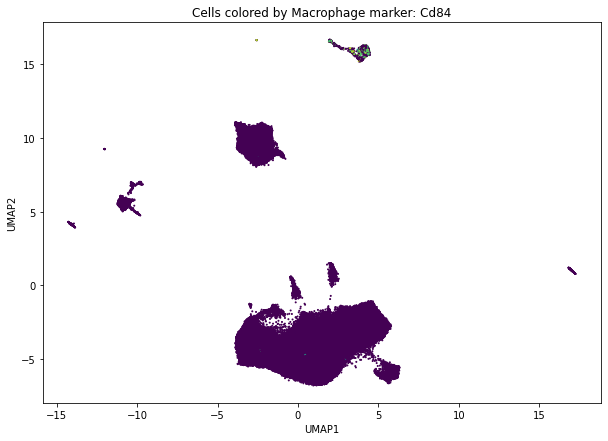

<Figure size 432x288 with 0 Axes>

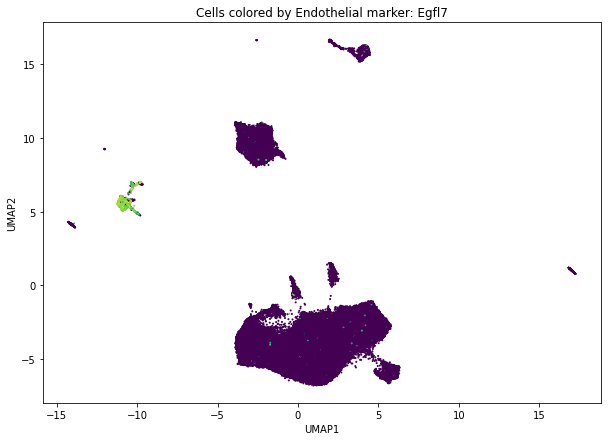

<Figure size 432x288 with 0 Axes>

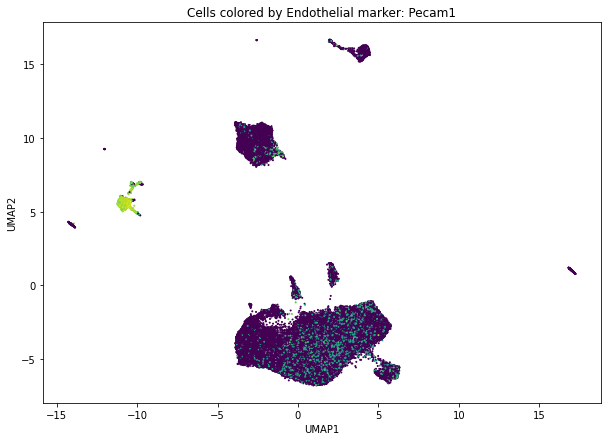

<Figure size 432x288 with 0 Axes>

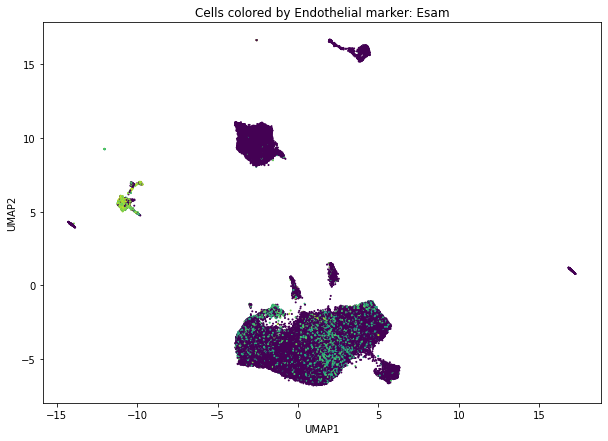

<Figure size 432x288 with 0 Axes>

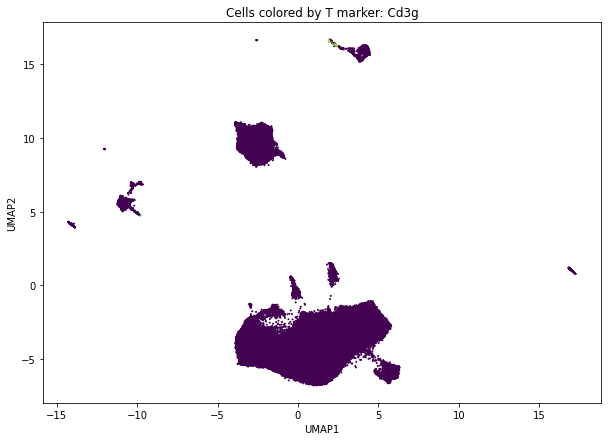

<Figure size 432x288 with 0 Axes>

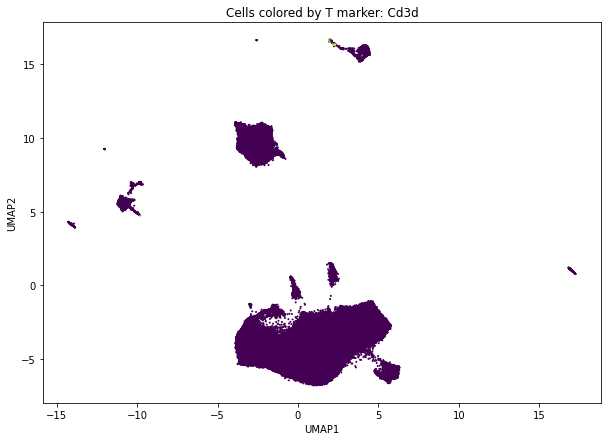

<Figure size 432x288 with 0 Axes>

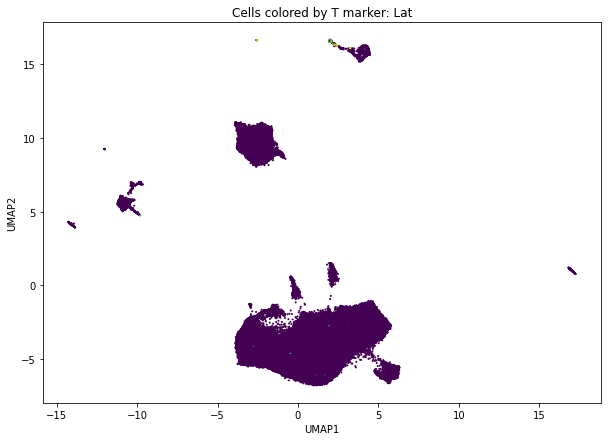

<Figure size 432x288 with 0 Axes>

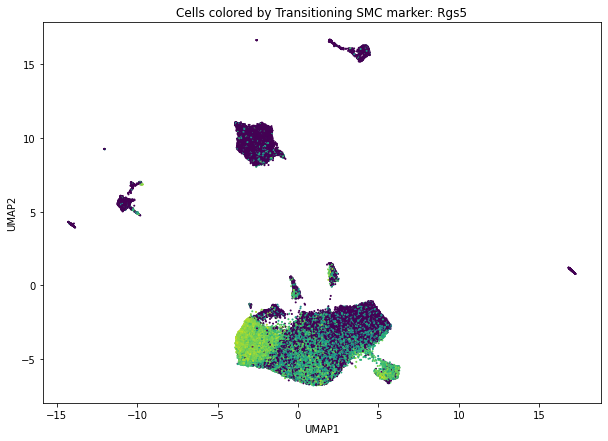

In [39]:
# --- VIZ CLUSTERS BY MARKERS ---

for cell_type, marker_list in marker_dict.items():
    for marker in marker_list:
        marker_index = np.where(adata.var_names == marker)[0]

        plt.clf()
        plt.figure(figsize=(10,7))
        plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c=X_transformed[:,marker_index].flatten())
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.title("Cells colored by %s marker: %s" % (cell_type, marker))
        plt.show()


